# Load data from spatial analysis

In [128]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/processed/station_spatial_summary.parquet")
print(df.shape)
df.head()

(2160, 17)


,start_station_id,total_trips,casual_trips,member_trips,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour,start_lat,start_lng,start_station_name,gi_zscore,gi_pvalue,hotspot_category
0,2009.04,221,124,97,0.561086,2190.059194,1280.789794,1.260496,2.356308,0.438914,20,40.61150,-74.03513,Shore Rd & 4 Ave,1.716563,0.001,hot spot
1,2158.08,197,56,141,0.284264,1188.031786,831.328362,1.315942,2.146326,0.248731,19,40.61689,-74.03091,4 Ave & 94 St,2.058648,0.001,hot spot
2,2190.08,195,71,124,0.364103,1471.565577,1297.978427,2.855367,4.115211,0.246154,14,40.61717,-74.02744,Fort Hamilton Pkwy & 92 St,1.621762,0.002,hot spot
3,2231.10,155,68,87,0.438710,1098.562206,899.890874,2.046109,2.715366,0.374194,7,40.61946,-74.03261,3 Ave & 92 St,1.410858,0.005,hot spot
4,2240.06,170,83,87,0.488235,1366.095120,914.267575,1.550043,2.259779,0.305882,19,40.61919,-74.04020,Shore Rd & Oliver St,1.915443,0.001,hot spot


# Select and prepare clustering features

In [129]:
print(df.columns.tolist())

['start_station_id', 'total_trips', 'casual_trips', 'member_trips', 'casual_share', 'avg_duration_casual', 'avg_duration_member', 'avg_distance_casual', 'avg_distance_member', 'weekend_trip_share', 'peak_hour', 'start_lat', 'start_lng', 'start_station_name', 'gi_zscore', 'gi_pvalue', 'hotspot_category']


In [130]:
# convert peak_hour to cyclical sin/cos components so hour 23 and hour 0
# are treated as close together, not far apart
df['peak_hour_sin'] = np.sin(2 * np.pi * df['peak_hour'] / 24)
df['peak_hour_cos'] = np.cos(2 * np.pi * df['peak_hour'] / 24)

In [131]:
cluster_features = [
    'casual_share',
    'avg_duration_casual',
    'avg_duration_member',
    'avg_distance_casual',
    'avg_distance_member',
    'weekend_trip_share',
    'peak_hour_sin',
    'peak_hour_cos',
]

X = df[cluster_features].copy()
print(X.shape)
X.describe()

(2160, 8)


,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos
count,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2.160000e+03
mean,0.221933,1096.715593,747.751865,2.244143,2.137291,0.254828,-0.529843,-2.569685e-01
std,0.072297,288.945563,137.563942,0.474882,0.448584,0.052562,0.724689,3.582771e-01
min,0.070784,495.205539,459.519805,0.259884,0.373804,0.000000,-1.000000,-1.000000e+00
25%,0.173314,915.104382,665.283185,1.963617,1.846168,0.224763,-1.000000,-5.000000e-01
50%,0.206988,1033.106634,728.250103,2.225227,2.092550,0.255400,-0.965926,-2.588190e-01
75%,0.253508,1211.278530,800.502421,2.483442,2.367313,0.286292,-0.500000,-1.836970e-16
max,0.724171,3334.499419,1877.748475,6.367784,5.183059,0.590303,1.000000,1.000000e+00


In [132]:
# check for any missing values before scaling — clustering can't handle NaN
X.isna().sum()

casual_share           0
avg_duration_casual    0
avg_duration_member    0
avg_distance_casual    0
avg_distance_member    0
weekend_trip_share     0
peak_hour_sin          0
peak_hour_cos          0
dtype: int64

# Scale the features

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [134]:
# quick check: scaled features should have mean ~0, std ~1
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe()

,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos
count,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03
mean,-5.263280e-17,-3.750087e-16,-6.315935e-16,-3.289550e-16,7.500173e-16,-1.052656e-16,-1.365163e-16,1.184238e-16
std,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00
min,-2.091150e+00,-2.082224e+00,-2.095744e+00,-4.179395e+00,-3.932141e+00,-4.849280e+00,-6.489215e-01,-2.074382e+00
25%,-6.726436e-01,-6.286764e-01,-5.996322e-01,-5.908652e-01,-6.491330e-01,-5.721396e-01,-6.489215e-01,-6.784910e-01
50%,-2.067517e-01,-2.201926e-01,-1.417979e-01,-3.984178e-02,-9.976269e-02,1.086737e-02,-6.018916e-01,-5.166422e-03
75%,4.368450e-01,3.965780e-01,3.835509e-01,5.040292e-01,5.128914e-01,5.987432e-01,4.118940e-02,7.173999e-01
max,6.948507e+00,7.746449e+00,8.216239e+00,8.685522e+00,6.791310e+00,6.383943e+00,2.111522e+00,3.509182e+00


# Choose the number of clusters

In [135]:
print(np.__version__)

2.0.2


In [136]:
from sklearn.cluster import KMeans

km_check_a = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
km_check_b = KMeans(n_clusters=4, random_state=99, n_init=10).fit_predict(X_scaled)

print(f"Cluster sizes (seed 42): {pd.Series(km_check_a).value_counts().sort_index().tolist()}")
print(f"Cluster sizes (seed 99): {pd.Series(km_check_b).value_counts().sort_index().tolist()}")

Cluster sizes (seed 42): [439, 770, 329, 622]
Cluster sizes (seed 99): [332, 626, 766, 436]


/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

In [137]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette score = {s:.3f}")

/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

k=2: silhouette score = 0.250
k=3: silhouette score = 0.226
k=4: silhouette score = 0.179
k=5: silhouette score = 0.187
k=6: silhouette score = 0.176
k=7: silhouette score = 0.189
k=8: silhouette score = 0.187
k=9: silhouette score = 0.189
k=10: silhouette score = 0.160


/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


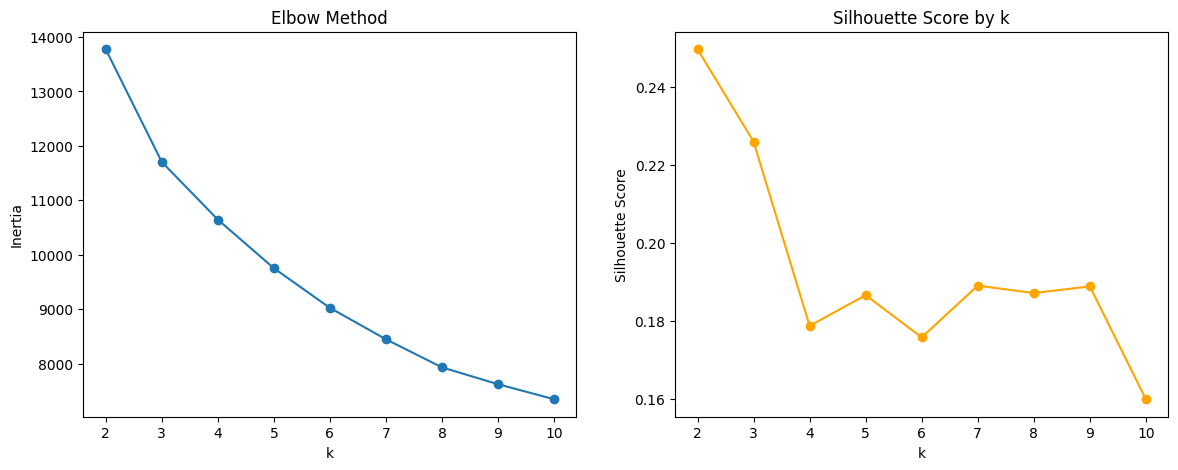

In [138]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
plt.show()

# Approach A - K-means

In [139]:
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best k by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

Best k by silhouette score: 2


In [140]:
df['kmeans_cluster'].value_counts().sort_index()

kmeans_cluster
0    1565
1     595
Name: count, dtype: int64

In [141]:
profile_cols = cluster_features + ['casual_share', 'total_trips']
df.groupby('kmeans_cluster')[profile_cols].mean()

,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos,casual_share,total_trips
kmeans_cluster,,,,,,,,,,
0,0.202449,1014.009195,692.348663,2.104812,1.958721,0.243037,-0.491596,-0.274128,0.202449,2704.212780
1,0.273178,1314.254268,893.476253,2.610619,2.606976,0.285844,-0.630440,-0.211834,0.273178,1888.152941


# Approach B - DBSCAN

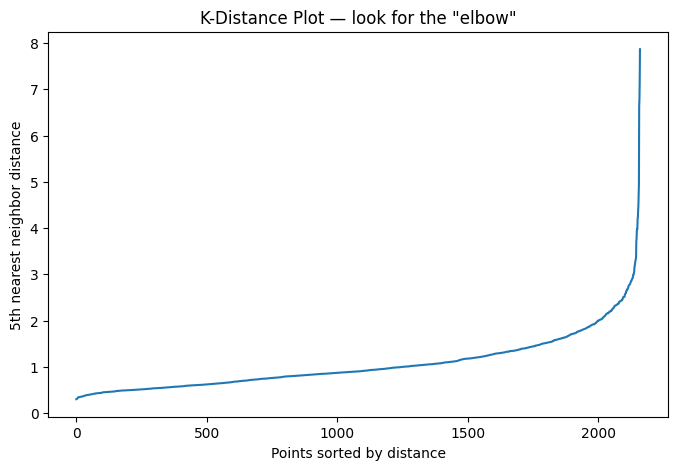

In [142]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# find a reasonable eps using a k-distance plot
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.title('K-Distance Plot — look for the "elbow"')
plt.show()

In [143]:
for eps_test in [1.3, 1.6, 1.8, 2.0]:
    labels = DBSCAN(eps=eps_test, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps_test}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.1f}%)")

eps=1.3: 2 clusters, 365 noise points (16.9%)
eps=1.6: 1 clusters, 192 noise points (8.9%)
eps=1.8: 2 clusters, 128 noise points (5.9%)
eps=2.0: 2 clusters, 96 noise points (4.4%)


In [144]:
# set eps based on where the elbow appears in the plot above 
eps = 1.8
min_samples = 5

df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'].value_counts().sort_index()

dbscan_cluster
-1     128
 0    2027
 1       5
Name: count, dtype: int64

# Compare Approaches

In [145]:
pd.crosstab(df['kmeans_cluster'], df['dbscan_cluster'])

dbscan_cluster,-1,0,1
kmeans_cluster,,,
0,27,1538,0
1,101,489,5


In [146]:
# checking which approach aligns better with the hot-spot analysis from notebook 03
print("K-means vs hot-spot:")
print(pd.crosstab(df['kmeans_cluster'], df['hotspot_category'], normalize='index'))
print("\nDBSCAN vs hot-spot:")
print(pd.crosstab(df['dbscan_cluster'], df['hotspot_category'], normalize='index'))

K-means vs hot-spot:
hotspot_category  cold spot  hot spot  not significant
kmeans_cluster                                        
0                  0.345687  0.086262         0.568051
1                  0.065546  0.290756         0.643697

DBSCAN vs hot-spot:
hotspot_category  cold spot  hot spot  not significant
dbscan_cluster                                        
-1                 0.039062  0.500000         0.460938
 0                 0.283670  0.119388         0.596941
 1                 0.000000  0.400000         0.600000


# Save results

In [147]:
output_path = "../data/processed/station_clustered_summary.parquet"
df.to_parquet(output_path, index=False)
print(f"Saved to {output_path}")
print(df.shape)

Saved to ../data/processed/station_clustered_summary.parquet
(2160, 21)
